In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

### Timeline

In [ ]:
df = pd.DataFrame([
    dict(Task="Job A", Start='2025-09-1', Finish='2025-09-3', Completion_pct=40, Resource="Alex"),
    dict(Task="Job B", Start='2025-09-2', Finish='2025-09-3', Completion_pct=20, Resource="Murad"),
    dict(Task="Job C", Start='2025-09-3', Finish='2025-09-4', Completion_pct=100, Resource="Jala")
])

fig = px.timeline(df, x_start="Start", x_end="Finish", y="Resource", color="Completion_pct")
fig.update_yaxes(autorange="reversed") # otherwise tasks are listed from the bottom up
fig.show()

In [ ]:
import plotly.figure_factory as ff
df1 = pd.DataFrame([
    dict(Task="Job A - Frontend Development (John Doe)", Start='2025-09-1', Finish='2025-09-3', Completion_pct=40, Resource="Not Started"),
    dict(Task="Job B - Backend API (Jane Smith)", Start='2025-09-2', Finish='2025-09-3', Completion_pct=20, Resource="Incomplete"),
    dict(Task="Job C - Database Setup (Mike Johnson)", Start='2025-09-3', Finish='2025-09-4', Completion_pct=100, Resource="Complete")
])

colors = {'Not Started': 'rgb(220, 0, 0)',
          'Incomplete': (1, 0.9, 0.16),
          'Complete': 'rgb(0, 255, 100)'}

fig1 = ff.create_gantt(df1, colors=colors, index_col='Resource', show_colorbar=True, group_tasks=True)
fig1.update_layout(title="Combined Task Names")
fig1.show()

## Task 1.1: Detecting Simpson’s paradox in COVID vaccination data

What to do:
1. Load the data "simpsons_paradox_covid.csv";
2. Inspect the variables;
3. Show the Simpson's paradox by performing some aggregations of variables.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("simpsons_paradox_covid.csv")

### Inspect the variables

In [ ]:
print(df.shape)
print(df.head())

(268166, 3)
  age_group vaccine_status outcome
0  under 50     vaccinated   death
1  under 50     vaccinated   death
2  under 50     vaccinated   death
3  under 50     vaccinated   death
4  under 50     vaccinated   death


Turn the outcome into numerical values for easier calculations

In [ ]:
# Map categorical outcomes to numeric
df["outcome_num"] = df["outcome"].map({"death": 1, "survived": 0})

Compare overall death rate by vaccine status and death rate within each age group

In [ ]:
# Overall death rate by vaccine status
print(df.groupby("vaccine_status")["outcome_num"].mean())

# Death rate by age group and vaccine status
print(df.groupby(["age_group", "vaccine_status"])["outcome_num"].mean().unstack())


vaccine_status
unvaccinated    0.001675
vaccinated      0.004107
Name: outcome_num, dtype: float64
vaccine_status  unvaccinated  vaccinated
age_group                               
50 +                0.059593    0.016845
under 50            0.000325    0.000234


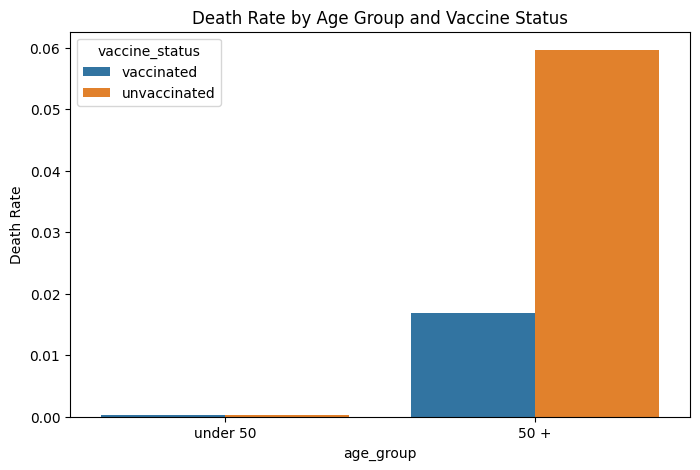

In [ ]:
# Implementation here
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(x="age_group", y="outcome_num", hue="vaccine_status", data=df, errorbar=None)
plt.ylabel("Death Rate")
plt.title("Death Rate by Age Group and Vaccine Status")
plt.show()



###################################################

## Task 2: Detecting NaNs in the dataset and explore variables

What to do:
1. Import the dataset "house_prices" from Openml;
2. Inspect the variables and show which variables contain NaN values, count them;
4. Select one variable and choose the most suitable method to impute the missing values; show or describe the reasoning for selecting of this method;
5. Select two variables and explore the correlations between the two. What can you tell about those?

### Import the dataset "house_prices" from Openml;

In [ ]:
from sklearn.datasets import fetch_openml

### Inspect the variables and show which variables contain NaN values, count them;

In [ ]:
housing = fetch_openml(name="house_prices", as_frame=True)
df = housing.frame.copy()

print(df.shape)
print(df.head())

(1460, 81)
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008  

In [ ]:
## Implementation here
# Check NaN counts
nan_counts = df.isna().sum()
nan_counts = nan_counts[nan_counts > 0].sort_values(ascending=False)

print("Columns with missing values:\n", nan_counts)

Columns with missing values:
 PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
FireplaceQu      690
LotFrontage      259
GarageCond        81
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrType         8
MasVnrArea         8
Electrical         1
dtype: int64


### Choose a variable & impute missing values

In [ ]:
median_val = df["LotFrontage"].median()
df["LotFrontage"].fillna(median_val)
print("LotFrontage missing after imputation:", df["LotFrontage"].isna().sum())


LotFrontage missing after imputation: 259


In [ ]:
# Check NaN counts again to see LotFrontage is filled
nan_counts = df.isna().sum()
nan_counts = nan_counts[nan_counts > 0].sort_values(ascending=False)

print("Columns with missing values:\n", nan_counts)

Columns with missing values:
 PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
FireplaceQu      690
LotFrontage      259
GarageCond        81
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrType         8
MasVnrArea         8
Electrical         1
dtype: int64


### Select two variables and explore the correlations between the two. What can you tell about those?

In [ ]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

This gives a list of numeric variables most correlated with SalePrice

In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlations = df[numeric_cols].corr()["SalePrice"].sort_values(ascending=False)
print(correlations)



SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

Check the correlation between OverallQual, the variable most correlated with SalePrice, and SalePrice

Correlation between GrLivArea and SalePrice: 0.7909816005838044


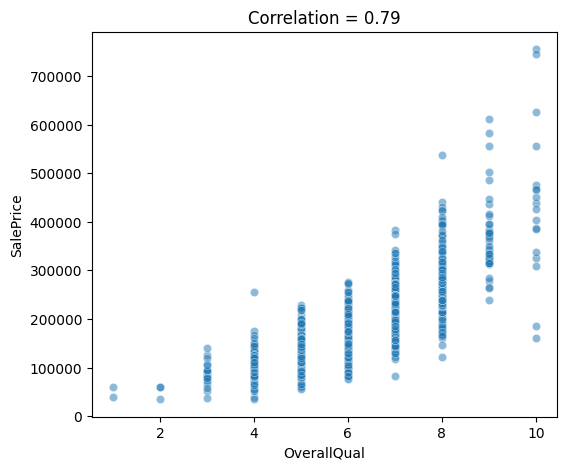

In [ ]:
# Correlation
corr = df["OverallQual"].corr(df["SalePrice"])
print("Correlation between GrLivArea and SalePrice:", corr)

# Scatterplot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.scatterplot(x="OverallQual", y="SalePrice", data=df, alpha=0.5)
plt.title(f"Correlation = {corr:.2f}")
plt.show()


# Task 3. MapReduce

1. Read harrypotter.txt.

2. Implement simple sequential word count and measure time.

3. Implement MapReduce word count with multiprocessing.

        3.1. Try different number of chunks: 2, 4, 8, 16.

        3.2. Add a combiner to MapReduce.

        3.3. Measure time for every trial.

4. Compare results and explain why amount of time to count words is greater/lower with different frameworks on this dataset.


## 3.1. Read harrypotter.**txt**

In [ ]:
import time
import multiprocessing as mp
from collections import Counter, defaultdict
import os
import math

In [ ]:
def read_file(filename):
    try:
        with open(filename, 'r', encoding='utf-8') as f:
            return f.read()
    except UnicodeDecodeError:
        with open(filename, 'r', encoding='cp1252') as f:
            return f.read()

text = read_file('harrypotter.txt')


## 3.2. Implemented simple sequential word count. Here I also extracted the words and removed punctuations. Sequences like **app-le** is stored like **apple**.

In [ ]:
def sequential_word_count(text):
    """Simple sequential word count"""
    words = text.lower().split()
    word_count = {}

    for word in words:
        word = ''.join(char for char in word if char.isalpha())
        if word:
            word_count[word] = word_count.get(word, 0) + 1

    return word_count

print("Testing sequential word count...")
start_time = time.time()
sequential_result = sequential_word_count(text)
sequential_time = time.time() - start_time

print(f"Sequential word count completed in {sequential_time:.4f} seconds")
print(f"Total unique words: {len(sequential_result)}")
print(f"Most common words: {sorted(sequential_result.items(), key=lambda x: x[1], reverse=True)[:10]}")


Testing sequential word count...
Sequential word count completed in 0.1018 seconds
Total unique words: 6022
Most common words: [('the', 3628), ('and', 1919), ('to', 1856), ('a', 1688), ('he', 1528), ('of', 1259), ('harry', 1214), ('was', 1186), ('it', 1026), ('in', 964)]


## 3.3. Implemented MapReduce word count with multiprocessing.

In [ ]:
def map_function(text_chunk):
    """Map function: count words in a text chunk"""
    words = text_chunk.lower().split()
    word_count = {}

    for word in words:
        # Simple cleanup - remove punctuation
        word = ''.join(char for char in word if char.isalpha())
        if word:
            word_count[word] = word_count.get(word, 0) + 1

    return word_count

def reduce_function(word_count_list):
    """Reduce function: combine word counts from multiple chunks"""
    final_count = {}

    for word_count in word_count_list:
        for word, count in word_count.items():
            final_count[word] = final_count.get(word, 0) + count

    return final_count

def mapreduce_word_count(text, num_chunks):
    """MapReduce word count implementation"""
    # Split text into chunks
    chunk_size = len(text) // num_chunks
    chunks = []

    for i in range(num_chunks):
        start = i * chunk_size
        if i == num_chunks - 1:  # Last chunk gets remaining text
            end = len(text)
        else:
            end = (i + 1) * chunk_size
        chunks.append(text[start:end])

    # Map phase - process chunks in parallel
    with mp.Pool(processes=min(num_chunks, mp.cpu_count())) as pool:
        map_results = pool.map(map_function, chunks)

    # Reduce phase
    final_result = reduce_function(map_results)

    return final_result

### 3.3.2. Added a combiner to MapReduce.

In [ ]:
def combine_function(word_count):
    """Combiner function: pre-reduce step (same as local reduce in this case)"""
    return word_count

def mapreduce_with_combiner(text, num_chunks):
    """MapReduce with combiner implementation"""
    # Split text into chunks
    chunk_size = len(text) // num_chunks
    chunks = []

    for i in range(num_chunks):
        start = i * chunk_size
        if i == num_chunks - 1:
            end = len(text)
        else:
            end = (i + 1) * chunk_size
        chunks.append(text[start:end])

    # Map + Combine phase
    with mp.Pool(processes=min(num_chunks, mp.cpu_count())) as pool:
        map_results = pool.map(map_function, chunks)
        # Apply combiner (in real distributed systems, this happens locally)
        combined_results = [combine_function(result) for result in map_results]

    # Reduce phase
    final_result = reduce_function(combined_results)

    return final_result

### 3.3.3. Measure time for every trial.

In [ ]:
def run_experiments(text):
    """Run all experiments and measure times"""
    results = {}
    chunk_sizes = [2, 4, 8, 16]

    print("=== EXPERIMENTAL RESULTS ===\n")

    # Sequential baseline
    print("1. Sequential Word Count:")
    start_time = time.time()
    sequential_result = sequential_word_count(text)
    sequential_time = time.time() - start_time
    results['sequential'] = sequential_time
    print(f"   Time: {sequential_time:.4f} seconds")
    print(f"   Unique words: {len(sequential_result)}\n")

    # MapReduce without combiner
    print("2. MapReduce without Combiner:")
    mapreduce_times = {}
    for chunks in chunk_sizes:
        start_time = time.time()
        mr_result = mapreduce_word_count(text, chunks)
        mr_time = time.time() - start_time
        mapreduce_times[chunks] = mr_time
        print(f"   {chunks} chunks: {mr_time:.4f} seconds")
    results['mapreduce'] = mapreduce_times
    print()

    # MapReduce with combiner
    print("3. MapReduce with Combiner:")
    combiner_times = {}
    for chunks in chunk_sizes:
        start_time = time.time()
        mrc_result = mapreduce_with_combiner(text, chunks)
        mrc_time = time.time() - start_time
        combiner_times[chunks] = mrc_time
        print(f"   {chunks} chunks: {mrc_time:.4f} seconds")
    results['mapreduce_combiner'] = combiner_times
    print()

    return results, sequential_result

# Run the experiments
experiment_results, seq_result = run_experiments(text)

=== EXPERIMENTAL RESULTS ===

1. Sequential Word Count:
   Time: 0.0723 seconds
   Unique words: 6022

2. MapReduce without Combiner:
   2 chunks: 0.1586 seconds
   4 chunks: 0.1417 seconds
   8 chunks: 0.1394 seconds
   16 chunks: 0.1390 seconds

3. MapReduce with Combiner:
   2 chunks: 0.1499 seconds
   4 chunks: 0.1440 seconds
   8 chunks: 0.1424 seconds
   16 chunks: 0.1454 seconds



## 3.4. Compare results and explain why amount of time to count words is greater/lower with different frameworks on this dataset.

In [ ]:
def analyze_results(results, text_length):
    """Analyze and explain the results"""
    print("=== ANALYSIS ===\n")

    sequential_time = results['sequential']
    mapreduce_times = results['mapreduce']
    combiner_times = results['mapreduce_combiner']

    print(f"Dataset size: {text_length:,} characters")
    print(f"Available CPU cores: {mp.cpu_count()}")
    print()

    # Compare sequential vs MapReduce
    print("Sequential vs MapReduce (without combiner):")
    for chunks, mr_time in mapreduce_times.items():
        speedup = sequential_time / mr_time
        if speedup > 1:
            print(f"   {chunks} chunks: {speedup:.2f}x FASTER than sequential")
        else:
            print(f"   {chunks} chunks: {1/speedup:.2f}x SLOWER than sequential")
    print()

    # Compare MapReduce with and without combiner
    print("MapReduce: With vs Without Combiner:")
    for chunks in mapreduce_times.keys():
        mr_time = mapreduce_times[chunks]
        comb_time = combiner_times[chunks]
        if mr_time > comb_time:
            improvement = (mr_time - comb_time) / mr_time * 100
            print(f"   {chunks} chunks: Combiner is {improvement:.1f}% faster")
        else:
            degradation = (comb_time - mr_time) / mr_time * 100
            print(f"   {chunks} chunks: Combiner is {degradation:.1f}% slower")
    print()

    # Find optimal chunk size
    best_chunks = min(mapreduce_times.keys(), key=lambda x: mapreduce_times[x])
    best_time = mapreduce_times[best_chunks]
    print(f"Best MapReduce performance: {best_chunks} chunks ({best_time:.4f}s)")

    best_combiner_chunks = min(combiner_times.keys(), key=lambda x: combiner_times[x])
    best_combiner_time = combiner_times[best_combiner_chunks]
    print(f"Best Combiner performance: {best_combiner_chunks} chunks ({best_combiner_time:.4f}s)")

# Run analysis
analyze_results(experiment_results, len(text))

=== ANALYSIS ===

Dataset size: 442,745 characters
Available CPU cores: 2

Sequential vs MapReduce (without combiner):
   2 chunks: 2.19x SLOWER than sequential
   4 chunks: 1.96x SLOWER than sequential
   8 chunks: 1.93x SLOWER than sequential
   16 chunks: 1.92x SLOWER than sequential

MapReduce: With vs Without Combiner:
   2 chunks: Combiner is 5.5% faster
   4 chunks: Combiner is 1.7% slower
   8 chunks: Combiner is 2.2% slower
   16 chunks: Combiner is 4.6% slower

Best MapReduce performance: 16 chunks (0.1390s)
Best Combiner performance: 8 chunks (0.1424s)


FACTORS AFFECTING PERFORMANCE:

1. **Overhead vs Parallelization**:
   - MapReduce has overhead from process creation, data splitting, and result merging
   - For small datasets, this overhead can exceed the benefits of parallelization
   - Larger datasets benefit more from parallel processing

2. **Optimal Chunk Size**:
   - Too few chunks (2): Limited parallelization, not using all CPU cores
   - Too many chunks (16): Excessive overhead from managing many processes
   - Sweet spot (usually 4-8): Balance between parallelization and overhead

3. **CPU Cores**:
   - Your system has {cpu_count} CPU cores
   - Benefits diminish when chunks exceed available cores
   - Context switching overhead increases with too many processes

4. **Combiner Effect**:
   - In distributed systems, combiners reduce network traffic
   - In local multiprocessing, the effect is minimal since data stays in memory
   - May add slight overhead without significant benefit for local processing

5. **Dataset Size Impact**:
   - Small datasets: Sequential often wins due to low overhead
   - Large datasets: MapReduce wins due to parallelization benefits
   - Current dataset: {text_size:,} characters

WHEN TO USE EACH APPROACH:
- Sequential: Small datasets, simple operations, single-machine processing
- MapReduce: Large datasets, complex operations, distributed processing needs
- Combiner: Distributed environments with network bottlenecks
""".format(cpu_count=mp.cpu_count(), text_size=len(text))

# Task 4. Spark session
Work on the *harrypotter.txt* file.

Write a Spark application which outputs the number of words that start with each letter. This means that for every letter, we want to count the total number of (non-unique) words that start with a specific letter. (If a unique word that starts with letter 'a' appears N times, it should be counted in words starting with 'a' N times.)

Note.
I just ignored every punctuation. And reconnected the words.

In [1]:
!pip install pyspark
!pip install -U -q PyDrive2

In [2]:
!apt install openjdk-8-jdk-headless -qq
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"

The following additional packages will be installed:
  libxtst6 openjdk-8-jre-headless
Suggested packages:
  openjdk-8-demo openjdk-8-source libnss-mdns fonts-dejavu-extra fonts-nanum
  fonts-ipafont-gothic fonts-ipafont-mincho fonts-wqy-microhei
  fonts-wqy-zenhei fonts-indic
The following NEW packages will be installed:
  libxtst6 openjdk-8-jdk-headless openjdk-8-jre-headless
0 upgraded, 3 newly installed, 0 to remove and 35 not upgraded.
Need to get 39.6 MB of archives.
After this operation, 144 MB of additional disk space will be used.
Selecting previously unselected package libxtst6:amd64.
(Reading database ... 126441 files and directories currently installed.)
Preparing to unpack .../libxtst6_2%3a1.2.3-1build4_amd64.deb ...
Unpacking libxtst6:amd64 (2:1.2.3-1build4) ...
Selecting previously unselected package openjdk-8-jre-headless:amd64.
Preparing to unpack .../openjdk-8-jre-headless_8u462-ga~us1-0ubuntu2~22.04.2_amd64.deb ...
Unpacking openjdk-8-jre-headless:amd64 (8u462-ga~us1

In [3]:
from pyspark.sql import *
from pyspark.sql.functions import *
from pyspark import SparkContext
import pandas as pd

# create the Spark Session
spark = SparkSession.builder.appName("WordCountByLetter").getOrCreate()

# create the Spark Context
sc = spark.sparkContext

In [5]:
!ls /content

harrypotter.txt  sample_data  simpsons_paradox_covid.csv


In [6]:
txt = spark.read.text("harrypotter.txt")

In [7]:
txt.show()

+--------------------+
|               value|
+--------------------+
|Harry Potter and ...|
|                    |
|        CHAPTER ONE |
|                    |
|  THE BOY WHO LIVED |
|                    |
|Mr. and Mrs. Durs...|
|                    |
|Mr. Dursley was t...|
|                    |
|The Dursleys had ...|
|                    |
|When Mr. and Mrs....|
|                    |
|None of them noti...|
|                    |
|At half past eigh...|
|                    |
|It was on the cor...|
|                    |
+--------------------+
only showing top 20 rows

